**Assignment-1**

Install and configure TensorFlow/Keras in Google Colab. Perform data preprocessing, normalization, train-test splitting, and data visualization on a sample dataset.

Dataset used: Fashion_MNIST (pre-integrated Keras dataset)

In [4]:
#Installed and configured TensorFlow/Keras and checked their versions:
import tensorflow as tf
print(f"TensorFlow Version: {tf.__version__}")
import keras
print(f"Keras Version: {keras.__version__}")

TensorFlow Version: 2.20.0
Keras Version: 3.13.2


In [5]:
# Using Keras to load the dataset
fm=tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test,y_test)=fm
X_train, y_train=X_train_full[: -5000], y_train_full[:-5000]
X_valid, y_valid=X_train_full[-5000 :], y_train_full[-5000 :]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [7]:
import numpy as np
import matplotlib.pyplot as plt

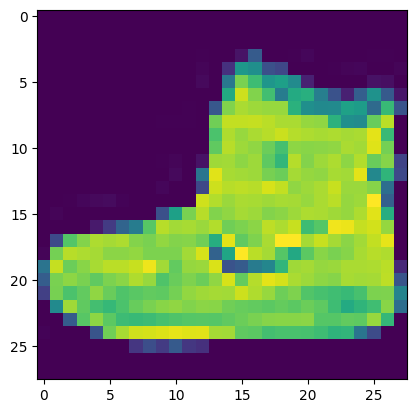

In [8]:
# Displaying the first image from the training dataset.
plt.figure()
plt.imshow(X_train[0])

In [9]:
X_train.shape, X_train.dtype

((55000, 28, 28), dtype('uint8'))

In [10]:
# Normalization
X_train, X_valid, X_test=X_train/255.0, X_valid/255.0, X_test/255.0

In [11]:
X_train.shape, X_train.dtype

((55000, 28, 28), dtype('float64'))

In [12]:
# Creating Sequential model
model= tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(28,28)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10,activation="softmax"))

In [13]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Prints information about the weights and biases of the first dense layer
weights,bias = model.layers[1].get_weights()
weights.shape, bias.shape ,weights, bias

((784, 300),
 (300,),
 array([[ 0.05682199, -0.03768079,  0.06792799, ...,  0.03129573,
         -0.02166924, -0.04126208],
        [-0.06722461,  0.04971273, -0.01533256, ..., -0.02905274,
         -0.01954912,  0.02832129],
        [-0.02887512,  0.0597194 , -0.01858336, ...,  0.01917449,
         -0.03415729,  0.02658787],
        ...,
        [ 0.07362969,  0.03827472, -0.05138165, ..., -0.01353324,
         -0.00243415,  0.01262145],
        [ 0.03999574,  0.05436458, -0.06643546, ...,  0.0224584 ,
         -0.04898853,  0.06760861],
        [ 0.06946459, -0.01130152,  0.01212859, ..., -0.02088785,
         -0.00546277, -0.05697248]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 

In [16]:
# Compiling the model
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [17]:
model.fit(X_test,  y_test, epochs=130)

Epoch 1/130
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6247 - loss: 1.2709
Epoch 2/130
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7514 - loss: 0.7378
Epoch 3/130
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7844 - loss: 0.6386
Epoch 4/130
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8026 - loss: 0.5829
Epoch 5/130
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8093 - loss: 0.5488
Epoch 6/130
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8194 - loss: 0.5283
Epoch 7/130
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8260 - loss: 0.5052
Epoch 8/130
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8298 - loss: 0.4895
Epoch 9/130
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8339 - loss: 0.4759
Epoch 10/130
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8347 - loss: 0.4685
Epoch 11/130
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8401 - loss: 0.4537
Epoch 12/130
313/313 ━━━━━━━━━━━━━━━━━━━━

In [18]:
# Training and evaluating model using accuracy
test_loss, test_acc = model.evaluate(X_test,  y_test, verbose=2)
print('\nTest accuracy:', test_acc)

313/313 - 2s - 5ms/step - accuracy: 0.9786 - loss: 0.0786

Test accuracy: 0.978600025177002
